# 04 Explainability and Conclusion

## Purpose
Interpret model behavior, highlight the most important findings and limitations, and conclude the project with a clear summary of what the analysis supports.

In [1]:
from pathlib import Path
from joblib import load
import json
import matplotlib.pyplot as plt
import pandas as pd


def print_section(title: str) -> None:
    print(f"\n{'=' * 12} {title} {'=' * 12}")


In [2]:
DATA_PATH = Path("Data/interim/cleaned_dataset.csv")
MODEL_PATH = Path("models/baseline_model.joblib")
MODEL_METADATA_PATH = Path("models/baseline_model_metadata.json")
TARGET_COLUMN = "No-show"

df = pd.read_csv(DATA_PATH)
model = load(MODEL_PATH)
metadata = json.loads(MODEL_METADATA_PATH.read_text(encoding="utf-8"))
X = df.drop(columns=[TARGET_COLUMN])


In [3]:
print_section("Model Type")
print(model.named_steps["model"].__class__.__name__)
print(f"Recommended operating threshold: {metadata['operating_threshold']:.2f}")


============ Model Type ============
LogisticRegression
Recommended operating threshold: 0.20



============ Global Explainability ============
Top features by overall influence:
Top features associated with lower no-show risk:
Top features associated with higher no-show risk:


num__same_day_appointment                 0.845865
cat__age_group_older                      0.517885
cat__Neighbourhood_SANTOS DUMONT          0.486740
cat__Neighbourhood_SOLON BORGES           0.451463
cat__Neighbourhood_DE LOURDES             0.447081
cat__Neighbourhood_ARIOVALDO FAVALESSA    0.391458
cat__age_group_mid_older                  0.385142
cat__Neighbourhood_ITARARÉ                0.349255
cat__scheduled_weekday_Saturday           0.323213
cat__Neighbourhood_DO CABRAL              0.321295
cat__Neighbourhood_COMDUSA                0.295179
cat__Gender_F                             0.264850
cat__Neighbourhood_JABOUR                 0.256401
cat__Neighbourhood_SANTA CLARA            0.247396
cat__Gender_M                             0.244989
Name: absolute_coefficient, dtype: float64

num__same_day_appointment         -0.845865
cat__age_group_older              -0.517885
cat__Neighbourhood_SOLON BORGES   -0.451463
cat__Neighbourhood_DE LOURDES     -0.447081
cat__age_group_mid_older          -0.385142
cat__scheduled_weekday_Saturday   -0.323213
cat__Neighbourhood_DO CABRAL      -0.321295
cat__Neighbourhood_COMDUSA        -0.295179
cat__Gender_F                     -0.264850
cat__Neighbourhood_JABOUR         -0.256401
Name: coefficient, dtype: float64

cat__Neighbourhood_SANTOS DUMONT          0.486740
cat__Neighbourhood_ARIOVALDO FAVALESSA    0.391458
cat__Neighbourhood_ITARARÉ                0.349255
cat__Neighbourhood_SANTA CLARA            0.247396
cat__Neighbourhood_SANTA CECÍLIA          0.243173
cat__Neighbourhood_HORTO                  0.242049
cat__Neighbourhood_JESUS DE NAZARETH      0.236229
cat__Neighbourhood_PARQUE MOSCOSO         0.224416
cat__age_group_child                      0.221570
cat__age_group_young_adult                0.220338
Name: coefficient, dtype: float64

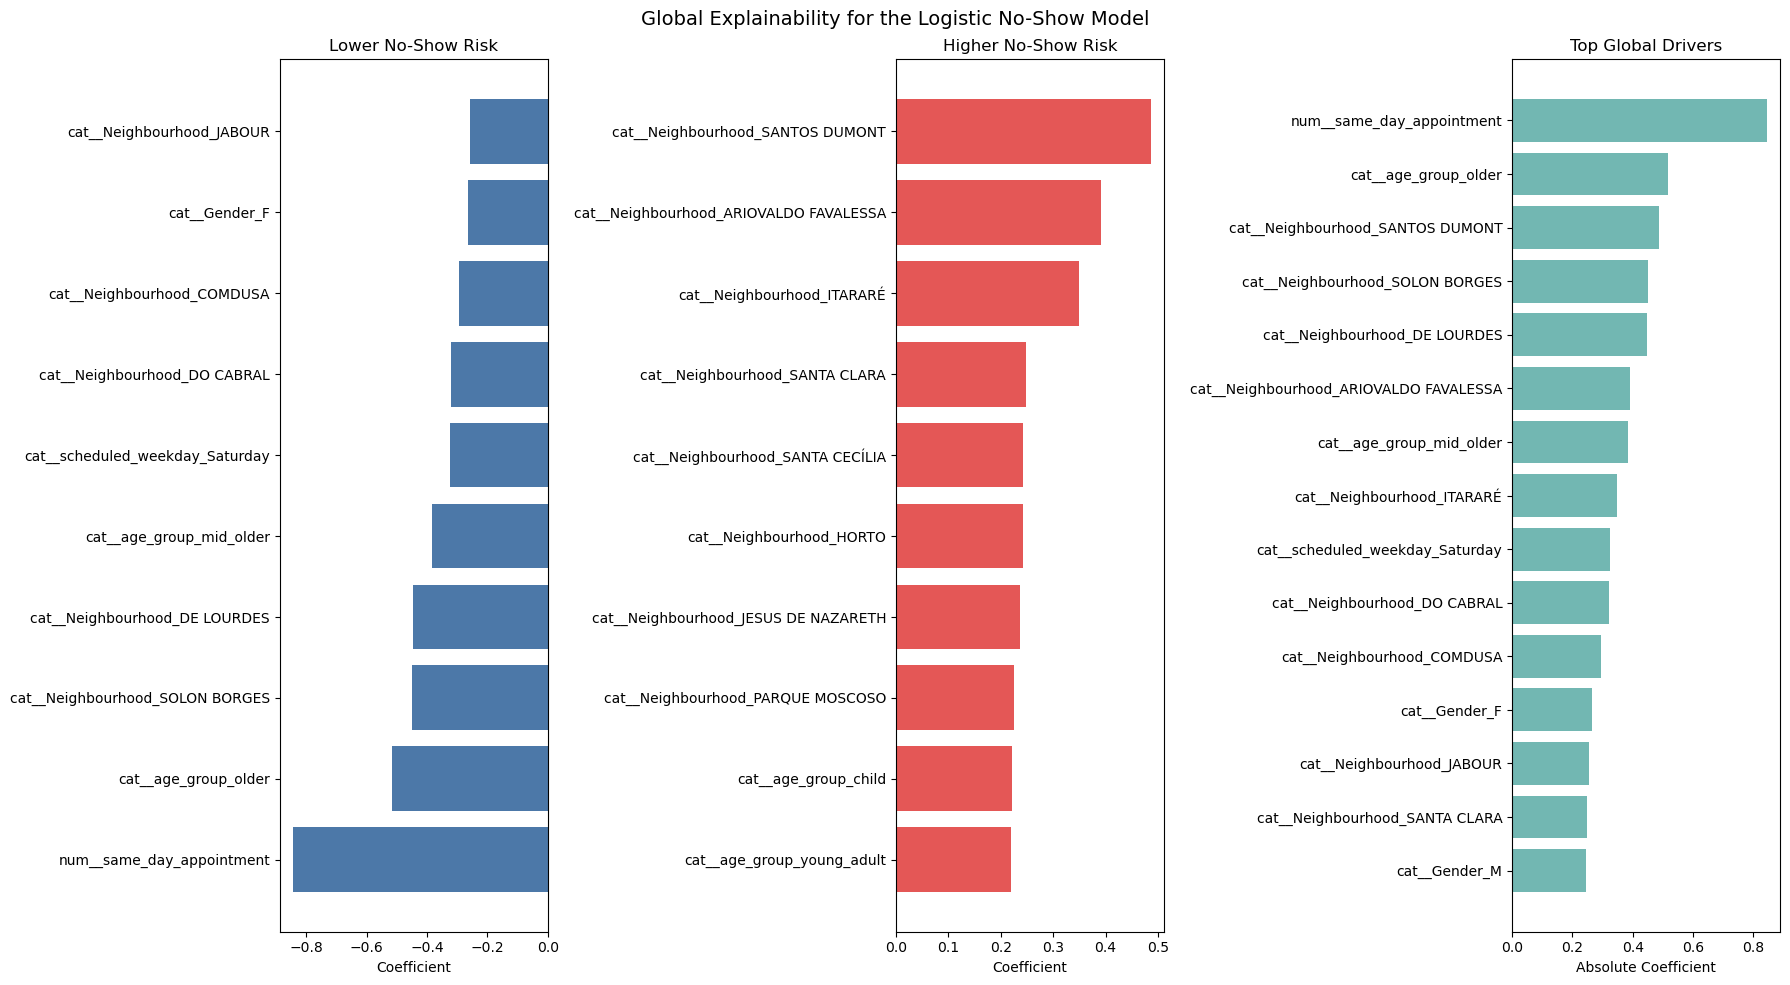

In [4]:
print_section("Global Explainability")
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
fitted_model = model.named_steps["model"]

if hasattr(fitted_model, "coef_"):
    coefficients = pd.Series(fitted_model.coef_.ravel(), index=feature_names).sort_values()
    absolute_coefficients = coefficients.abs().sort_values(ascending=False)
    print("Top features by overall influence:")
    display(absolute_coefficients.head(15).rename("absolute_coefficient"))
    print("Top features associated with lower no-show risk:")
    display(coefficients.head(10).rename("coefficient"))
    print("Top features associated with higher no-show risk:")
    display(coefficients.tail(10).sort_values(ascending=False).rename("coefficient"))

    top_negative = coefficients.head(10).sort_values(ascending=True)
    top_positive = coefficients.tail(10).sort_values(ascending=True)
    top_global = absolute_coefficients.head(15).sort_values(ascending=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 10))
    axes[0].barh(top_negative.index, top_negative.values, color="#4C78A8")
    axes[0].set_title("Lower No-Show Risk")
    axes[0].set_xlabel("Coefficient")

    axes[1].barh(top_positive.index, top_positive.values, color="#E45756")
    axes[1].set_title("Higher No-Show Risk")
    axes[1].set_xlabel("Coefficient")

    axes[2].barh(top_global.index, top_global.values, color="#72B7B2")
    axes[2].set_title("Top Global Drivers")
    axes[2].set_xlabel("Absolute Coefficient")

    fig.suptitle("Global Explainability for the Logistic No-Show Model", fontsize=14)
    plt.tight_layout()
elif hasattr(fitted_model, "feature_importances_"):
    importances = pd.Series(fitted_model.feature_importances_, index=feature_names).sort_values(ascending=False)
    display(importances.head(15).rename("importance"))
    plt.figure(figsize=(8, 6))
    importances.head(15).sort_values().plot(kind="barh", color="#72B7B2")
    plt.title("Top Global Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
else:
    print("Use a model-specific explanation approach if needed.")

## Key Findings
- Lead time remains one of the clearest signals associated with higher no-show risk, and the added same-day and long-wait flags help make that operational relationship easier to explain.
- Several neighborhood indicators also carry strong coefficients, suggesting that attendance risk varies with local access barriers or service context.
- These patterns are most useful as prioritization signals for reminders and scheduling support, not as causal claims about individual patients.

## Limitations
- Administrative appointment data does not fully capture social, transportation, or clinical factors that may drive no-shows.
- Performance may shift across service lines, clinics, or time periods if scheduling workflows or patient populations differ from the training sample.
- Any operational use should include fairness and monitoring checks so the model does not unintentionally reinforce unequal access patterns.

## Next Steps
- Validate the approach on a later time period or a different clinic population to assess temporal and operational stability.
- Compare threshold options against available staffing so the intervention list remains actionable for scheduling or care coordination teams.
- Consider additional pre-visit data sources only if they improve prediction without creating privacy, fairness, or deployment concerns.

## Conclusion
This project shows that routine outpatient scheduling data can support a practical no-show risk stratification workflow when the feature set is limited to information available before the visit. The final logistic model is still simple and interpretable, but it becomes much more operationally useful once the threshold is tuned for outreach rather than left at the default cutoff. In practice, its best role is to help clinics rank appointments for targeted reminder or re-engagement efforts.